# Sign Language Letter Classification with a CNN from Scratch
**Author: Eng. Noureldin Bassem Mohamed**

## 1. Introduction

A company that is building real time captioning tools for American Sign Language needs one core building
block first: a model that looks at a single photo of a hand shape and says which letter it is. A full
fingerspelling reader would later sit on top of that, reading a sequence of hand shapes and turning them
into text, so the single letter classifier is the piece everything else depends on.

I build that classifier here on the **Sign Language MNIST** dataset, 27,455 training rows and 7,172 test
rows, every row a 28x28 grayscale hand sign flattened into 784 pixel columns. The labels cover the ASL
alphabet except **J** and **Z**, which both need movement and cannot be captured in a still photo, so the
problem has **24 classes**.

The whole model is designed and trained from scratch, no pretrained backbone. The plan is: look at the
data, prepare it, design a small CNN and justify every choice, train it, then judge it on the test CSV
that the model never sees during training or tuning, with per class metrics and not only overall accuracy.

## 2. Import Libraries

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
import keras
from keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

## 3. Loading Data

The dataset ships as two CSV files, one for training and one for testing. I download it with `kagglehub`
so the notebook runs anywhere instead of depending on a path from my own machine.

In [2]:
import kagglehub

data_dir=kagglehub.dataset_download("datamunge/sign-language-mnist")

train_df=pd.read_csv(os.path.join(data_dir,"sign_mnist_train.csv"))
test_df=pd.read_csv(os.path.join(data_dir,"sign_mnist_test.csv"))

print("train:",train_df.shape)
print("test :",test_df.shape)
train_df.head()

train: (27455, 785)
test : (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


## 4. Variables Initialization

In [3]:
img_size=28
n_channels=1
batch_size=128
epochs=30
seed=42
val_split=0.1

artifacts="artifacts"
os.makedirs(artifacts, exist_ok=True)

keras.utils.set_random_seed(seed)
sns.set_theme(style="whitegrid")

## 5. Exploratory Data Analysis

### 5.1 The raw table

Every row is one image: a `label` column then `pixel1 ... pixel784`. Before reshaping anything I check the
value range, missing values and which labels actually appear.

In [4]:
pixel_cols=[c for c in train_df.columns if c!="label"]

print("pixel columns:",len(pixel_cols))
print("missing values:",int(train_df.isna().sum().sum()+test_df.isna().sum().sum()))
print("pixel min/max:",train_df[pixel_cols].values.min(),train_df[pixel_cols].values.max())
print("labels in train:",sorted(train_df["label"].unique()))
print("labels in test :",sorted(test_df["label"].unique()))

pixel columns: 784
missing values: 0


pixel min/max: 0 255
labels in train: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
labels in test : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


The labels run 0-24 but **9 (J)** and **25 (Z)** never appear, exactly as the dataset description says, so
there are 24 classes. Because the label numbers have a hole in them I map every label to a contiguous
index 0-23 and keep a letter name for each index, both for the plots here and for the Streamlit app later.

In [5]:
present_labels=np.sort(train_df["label"].unique())
label_to_index={int(l):i for i,l in enumerate(present_labels)}
class_names=[chr(ord("A")+int(l)) for l in present_labels]

n_classes=len(class_names)
print("n_classes:",n_classes)
print(class_names)

n_classes: 24
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


### 5.2 Class balance

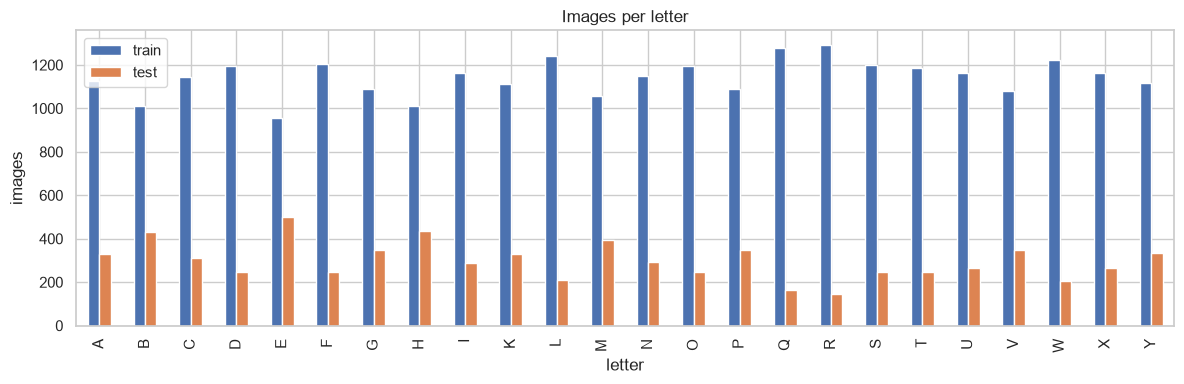

            train        test
min    957.000000  144.000000
max   1294.000000  498.000000
mean  1143.958333  298.833333
imbalance ratio (max/min) in train: 1.35


In [6]:
train_counts=train_df["label"].map(label_to_index).value_counts().sort_index()
test_counts=test_df["label"].map(label_to_index).value_counts().sort_index()

counts=pd.DataFrame({"train":train_counts.values,"test":test_counts.values},index=class_names)

fig,ax=plt.subplots(figsize=(12,4))
counts.plot(kind="bar",ax=ax)
ax.set_title("Images per letter")
ax.set_xlabel("letter")
ax.set_ylabel("images")
plt.tight_layout()
plt.show()

print(counts.describe().loc[["min","max","mean"]])
print("imbalance ratio (max/min) in train:",round(train_counts.max()/train_counts.min(),2))

The classes are close to balanced, roughly 1000-1300 images per letter in train, a max/min ratio near 1.3.
That is mild enough that I do not need class weights or resampling, and it also means plain accuracy is
not misleading here, though I still report macro F1 and per class scores because a single weak letter can
hide inside a good average.

### 5.3 What the images actually look like

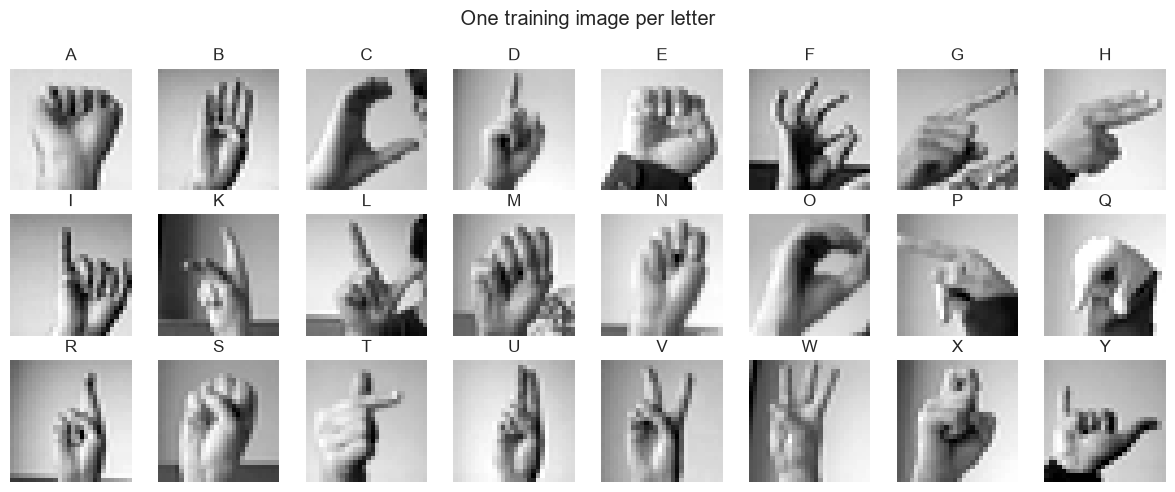

In [7]:
def to_images(df):
    x=df.drop(columns="label").values.reshape(-1,img_size,img_size,n_channels).astype("float32")
    y=df["label"].map(label_to_index).values.astype("int32")
    return x,y


x_train_full,y_train_full=to_images(train_df)
x_test,y_test=to_images(test_df)

fig,axes=plt.subplots(3,8,figsize=(12,5))
for i,ax in enumerate(axes.ravel()):
    idx=np.where(y_train_full==i)[0][0]
    ax.imshow(x_train_full[idx].squeeze(),cmap="gray")
    ax.set_title(class_names[i])
    ax.axis("off")
plt.suptitle("One training image per letter")
plt.tight_layout()
plt.show()

The hands are already cropped tight, lit from one side and shot against a plain background, and the
letters differ mostly by finger position inside a very similar hand blob. That is the whole difficulty of
this dataset: the useful signal is small local shape detail, not global layout, which is an argument for
small 3x3 filters and enough depth to combine them.

### 5.4 Which hand shapes look alike

Before training I want a guess at which letters the model will confuse. I average every image of a class
and compare those class averages with cosine similarity, the most similar pairs are the ones to watch in
the confusion matrix later.

In [8]:
class_means=np.stack([x_train_full[y_train_full==i].mean(axis=0).ravel() for i in range(n_classes)])

norm=class_means/np.linalg.norm(class_means,axis=1,keepdims=True)
similarity=norm@norm.T
np.fill_diagonal(similarity,0)

pairs=[]
for i in range(n_classes):
    for j in range(i+1,n_classes):
        pairs.append((class_names[i],class_names[j],similarity[i,j]))

pairs_df=pd.DataFrame(pairs,columns=["letter_a","letter_b","cosine_similarity"])
pairs_df=pairs_df.sort_values("cosine_similarity",ascending=False).head(10).reset_index(drop=True)
pairs_df

,letter_a,letter_b,cosine_similarity
0,R,U,0.999073
1,R,V,0.998654
2,R,W,0.998573
3,M,N,0.998462
4,M,S,0.998292
5,V,W,0.998263
6,U,V,0.998005
7,U,W,0.997929
8,I,S,0.997614
9,V,Y,0.997609


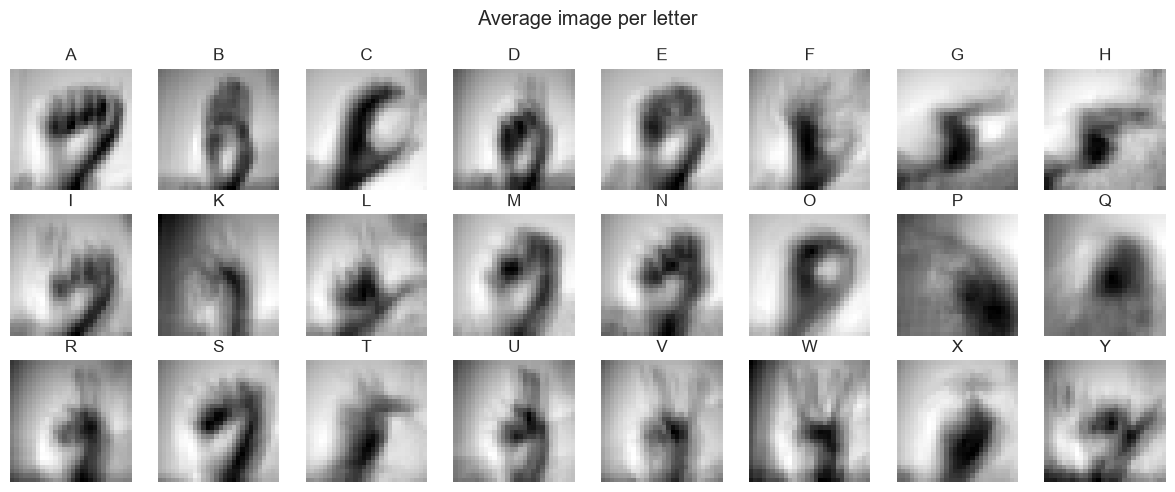

In [9]:
fig,axes=plt.subplots(3,8,figsize=(12,5))
for i,ax in enumerate(axes.ravel()):
    ax.imshow(class_means[i].reshape(img_size,img_size),cmap="gray")
    ax.set_title(class_names[i])
    ax.axis("off")
plt.suptitle("Average image per letter")
plt.tight_layout()
plt.show()

The top of the list is two families. **R with U, V and W**, all of them two extended fingers held
straight up, differing only in whether the fingers cross, split or add a third. And **M with N and S**,
which are all a closed fist with the thumb tucked in a slightly different place, a couple of pixels of
difference at 28x28. Those are the pairs to look for in the confusion matrix later.

## 6. Preprocessing

Three things happen here.

**Reshape and normalize.** Each 784 value row becomes a 28x28x1 image and pixels are divided by 255 so
they land in [0,1], which keeps the gradients well scaled for the batch norm layers.

**A validation split carved out of the training CSV.** The test CSV is held out completely, it is only
touched once at the end, so every decision I make about architecture, epochs or learning rate is judged on
a stratified 10% validation slice of the training data instead.

**Light augmentation.** The dataset was already built by augmenting a small set of original photos, so
heavy augmentation would mostly duplicate what is already there. I still add small rotation, zoom and
translation because images inside one class are near duplicates of each other and the model overfits them
quickly, and because a real photo uploaded to the app will never be framed exactly like the dataset. I
deliberately do **not** use horizontal flips: mirroring a hand sign turns it into a left handed version of
the sign and, for shapes that are not symmetric, into something that reads as a different letter.

In [10]:
x_train_full=x_train_full/255.0
x_test=x_test/255.0

x_train,x_val,y_train,y_val=train_test_split(
    x_train_full,y_train_full,
    test_size=val_split,
    random_state=seed,
    stratify=y_train_full
)

print("train:",x_train.shape)
print("val  :",x_val.shape)
print("test :",x_test.shape)

train: (24709, 28, 28, 1)
val  : (2746, 28, 28, 1)
test : (7172, 28, 28, 1)


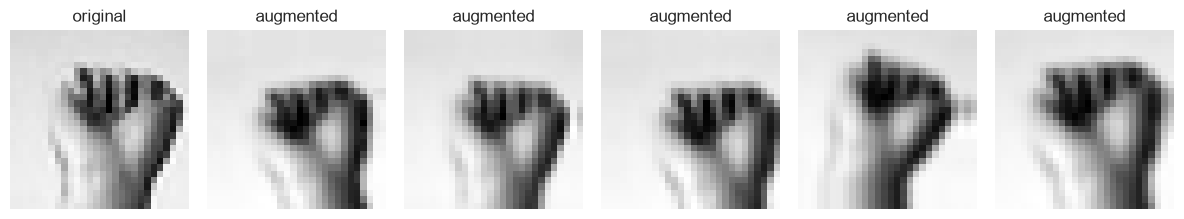

In [11]:
augmentation=keras.Sequential([
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10,0.10),
],name="augmentation")

sample=x_train[:1]

fig,axes=plt.subplots(1,6,figsize=(12,2.4))
axes[0].imshow(sample[0].squeeze(),cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")
for ax in axes[1:]:
    ax.imshow(augmentation(sample,training=True)[0].numpy().squeeze(),cmap="gray")
    ax.set_title("augmented")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. The CNN Architecture

The design, and why each piece is there:

- **Three convolutional stages of 3x3 filters, widths 32 to 64 to 128.** 28x28 is a small image, so I can
  only afford two downsamplings before the feature map stops meaning anything. Stacked 3x3 filters are the
  cheapest way to grow the receptive field, and the widths double as the resolution halves so the amount
  of information carried per stage stays roughly constant. The first two stages use two conv layers each,
  a single layer at high resolution was not enough to separate the fist shaped letters.
- **Batch normalization after every convolution.** It lets me train at a higher learning rate and it
  stabilizes a network this deep with no pretrained weights to start from.
- **Max pooling twice, 28 to 14 to 7.** After the third stage a global average pooling would throw away
  the exact finger positions, which is the only thing separating M, N and S, so I keep the spatial map and
  flatten it instead.
- **Dropout that grows with depth, 0.25, 0.25, 0.30 and 0.50.** The dataset is a small set of original
  photos augmented many times, so training images inside a class are near duplicates and the network
  memorizes them very fast. The classifier head is where that hurts most, hence 0.5 there.
- **A single Dense(256) head, then softmax over 24 classes.** Anything wider overfit without improving
  validation accuracy.
- **Adam at 1e-3 with `ReduceLROnPlateau`**, and sparse categorical crossentropy so the integer labels can
  be used directly.

In [12]:
def conv_block(x,filters,n_convs,dropout):
    for _ in range(n_convs):
        x=layers.Conv2D(filters,3,padding="same",use_bias=False)(x)
        x=layers.BatchNormalization()(x)
        x=layers.Activation("relu")(x)
    x=layers.MaxPooling2D()(x)
    x=layers.Dropout(dropout)(x)
    return x


def build_model():
    inputs=keras.Input(shape=(img_size,img_size,n_channels))

    x=augmentation(inputs)
    x=conv_block(x,32,2,0.25)
    x=conv_block(x,64,2,0.25)

    x=layers.Conv2D(128,3,padding="same",use_bias=False)(x)
    x=layers.BatchNormalization()(x)
    x=layers.Activation("relu")(x)
    x=layers.Dropout(0.30)(x)

    x=layers.Flatten()(x)
    x=layers.Dense(256,activation="relu")(x)
    x=layers.Dropout(0.50)(x)
    outputs=layers.Dense(n_classes,activation="softmax")(x)

    return keras.Model(inputs,outputs,name="asl_cnn_from_scratch")


model=build_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "asl_cnn_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,751,864 (6.68 MB)

 Trainable params: 1,751,224 (6.68 MB)

 Non-trainable params: 640 (2.50 KB)

## 8. Training

`EarlyStopping` watches validation accuracy and restores the best weights, `ReduceLROnPlateau` cuts the
learning rate when validation loss stops improving. Together they make the epoch count an upper bound
rather than something I have to guess exactly.

In [13]:
callbacks=[
    keras.callbacks.EarlyStopping(monitor="val_accuracy",patience=6,restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=3,min_lr=1e-5),
]

history=model.fit(
    x_train,y_train,
    validation_data=(x_val,y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/30


194/194 - 23s - 121ms/step - accuracy: 0.1693 - loss: 2.7495 - val_accuracy: 0.0586 - val_loss: 3.2485 - learning_rate: 0.0010


Epoch 2/30


194/194 - 21s - 108ms/step - accuracy: 0.3758 - loss: 1.8187 - val_accuracy: 0.4454 - val_loss: 1.7217 - learning_rate: 0.0010


Epoch 3/30


...

194/194 - 21s - 108ms/step - accuracy: 0.9296 - loss: 0.1914 - val_accuracy: 1.0000 - val_loss: 0.0014 - learning_rate: 5.0000e-04


Epoch 26/30


194/194 - 21s - 106ms/step - accuracy: 0.9338 - loss: 0.1760 - val_accuracy: 1.0000 - val_loss: 5.2832e-04 - learning_rate: 5.0000e-04


Epoch 27/30


194/194 - 21s - 109ms/step - accuracy: 0.9381 - loss: 0.1647 - val_accuracy: 0.9989 - val_loss: 0.0033 - learning_rate: 5.0000e-04


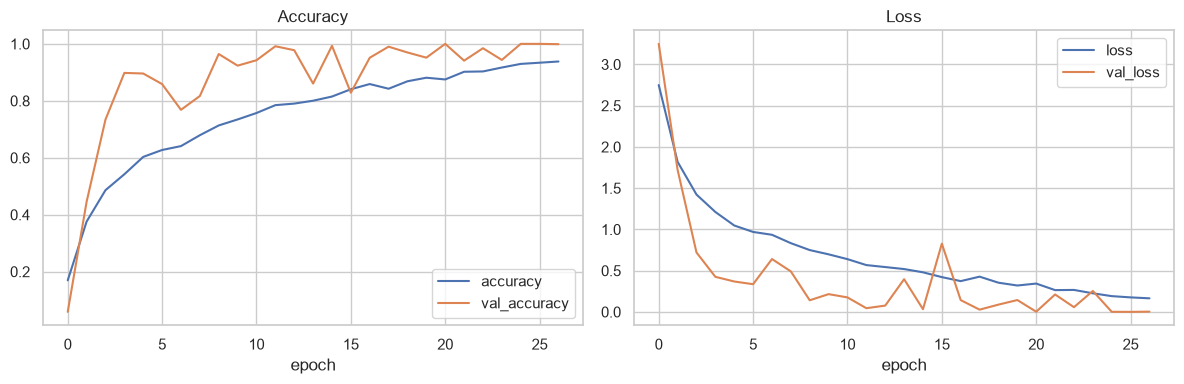

epochs run: 27
best val accuracy: 1.0


In [14]:
hist=pd.DataFrame(history.history)

fig,axes=plt.subplots(1,2,figsize=(12,4))
hist[["accuracy","val_accuracy"]].plot(ax=axes[0])
axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
hist[["loss","val_loss"]].plot(ax=axes[1])
axes[1].set_title("Loss")
axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

print("epochs run:",len(hist))
print("best val accuracy:",round(hist["val_accuracy"].max(),4))

## 9. Evaluation on the Held Out Test Set

This is the first and only time the test CSV is used. For a 24 class problem overall accuracy alone is not
enough, so I report **macro F1**, where every letter counts the same regardless of how many samples it
has, **balanced accuracy**, the mean per class recall, a full per class report, and the confusion matrix.

In [15]:
probabilities=model.predict(x_test,batch_size=256,verbose=0)
y_pred=probabilities.argmax(axis=1)

print("accuracy         :",round(accuracy_score(y_test,y_pred),4))
print("balanced accuracy:",round(balanced_accuracy_score(y_test,y_pred),4))
print("macro F1         :",round(f1_score(y_test,y_pred,average="macro"),4))
print("weighted F1      :",round(f1_score(y_test,y_pred,average="weighted"),4))

accuracy         : 0.9958
balanced accuracy: 0.9964
macro F1         : 0.9955
weighted F1      : 0.9958


In [16]:
print(classification_report(y_test,y_pred,target_names=class_names,digits=3))

              precision    recall  f1-score   support

           A      1.000     1.000     1.000       331
           B      1.000     1.000     1.000       432
           C      1.000     1.000     1.000       310
           D      1.000     1.000     1.000       245
           E      1.000     1.000     1.000       498
           F      1.000     1.000     1.000       247
           G      1.000     1.000     1.000       348
           H      1.000     1.000     1.000       436
           I      1.000     1.000     1.000       288
           K      1.000     1.000     1.000       331
           L      0.905     1.000     0.950       209
           M      1.000     0.980     0.990       394
           N      0.973     1.000     0.986       291
           O      1.000     1.000     1.000       246
           P      1.000     1.000     1.000       347
           Q      1.000     1.000     1.000       164
           R      1.000     1.000     1.000       144
           S      1.000    

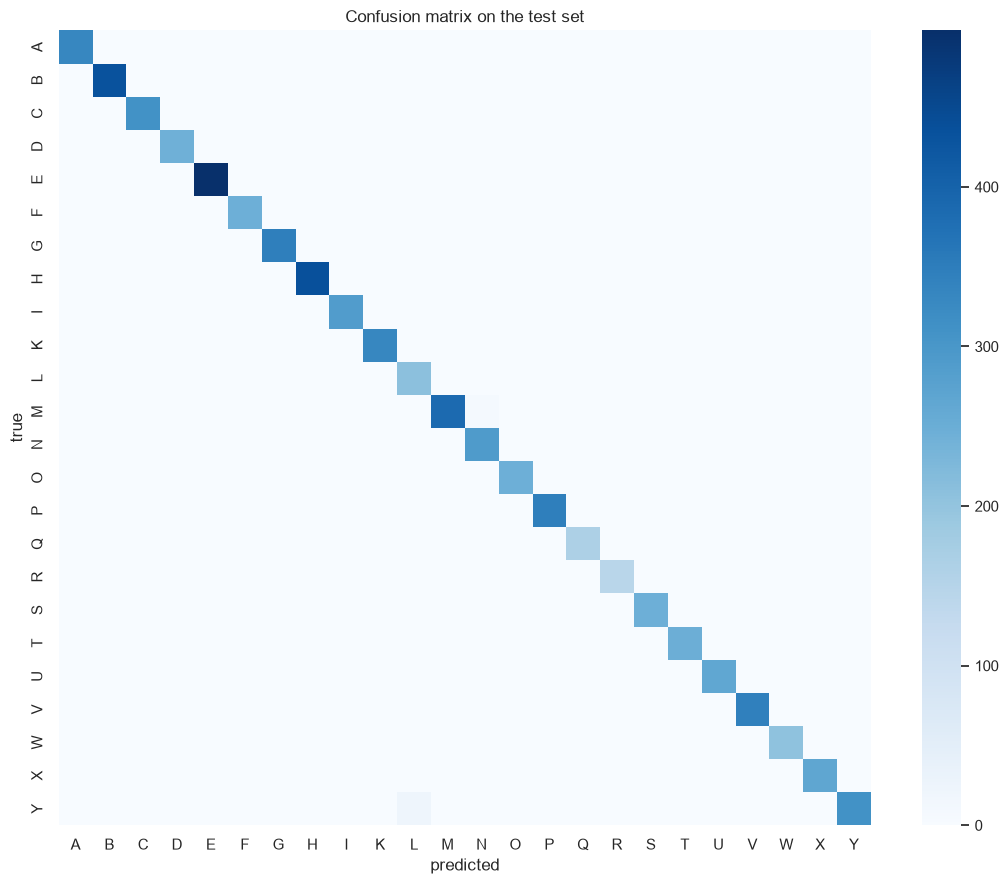

In [17]:
cm=confusion_matrix(y_test,y_pred)

fig,ax=plt.subplots(figsize=(11,9))
sns.heatmap(cm,cmap="Blues",xticklabels=class_names,yticklabels=class_names,ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix on the test set")
plt.tight_layout()
plt.show()

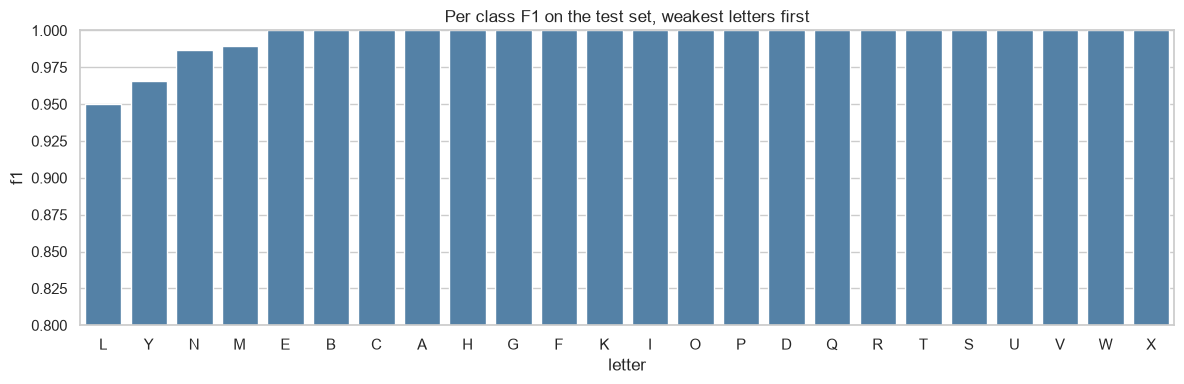

,letter,f1,support
0,L,0.950000,209
1,Y,0.965732,332
2,N,0.986441,291
3,M,0.989744,394
4,E,1.000000,498
5,B,1.000000,432


In [18]:
per_class=pd.DataFrame({
    "letter":class_names,
    "f1":f1_score(y_test,y_pred,average=None),
    "support":np.bincount(y_test,minlength=n_classes)
}).sort_values("f1")

fig,ax=plt.subplots(figsize=(12,4))
sns.barplot(data=per_class,x="letter",y="f1",order=per_class["letter"],color="steelblue",ax=ax)
ax.set_ylim(min(0.8,per_class["f1"].min()-0.02),1.0)
ax.set_title("Per class F1 on the test set, weakest letters first")
plt.tight_layout()
plt.show()

per_class.head(6).reset_index(drop=True)

In [19]:
errors=cm.copy()
np.fill_diagonal(errors,0)

rows=[]
for i in range(n_classes):
    for j in range(n_classes):
        if errors[i,j]>0:
            rows.append({
                "true":class_names[i],
                "predicted":class_names[j],
                "count":int(errors[i,j]),
                "share_of_true_class":round(errors[i,j]/cm[i].sum(),3)
            })

confusions=pd.DataFrame(rows).sort_values("count",ascending=False).head(10).reset_index(drop=True)
confusions

,true,predicted,count,share_of_true_class
0,Y,L,22,0.066
1,M,N,8,0.020


misclassified images: 30 out of 7172


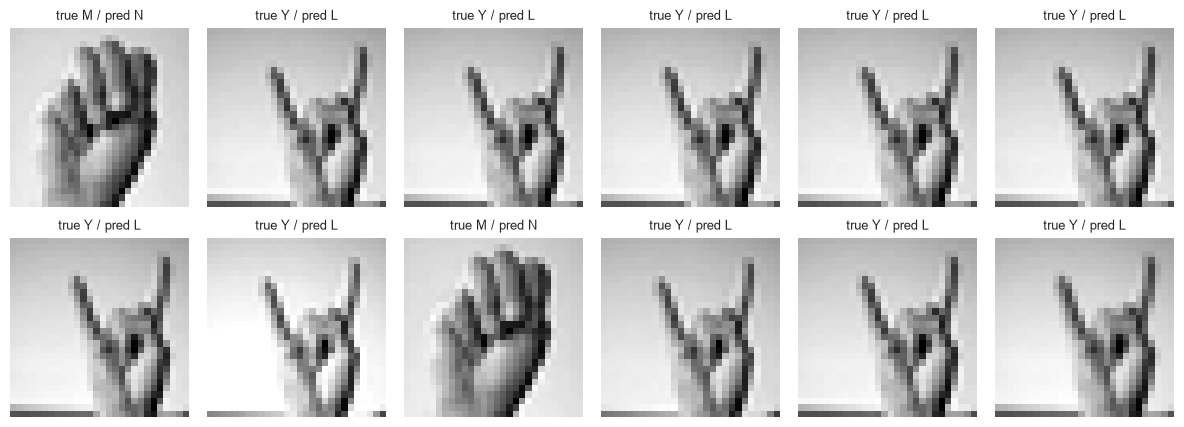

In [20]:
wrong=np.where(y_pred!=y_test)[0]
print("misclassified images:",len(wrong),"out of",len(y_test))

show=wrong[:12]
if len(show):
    fig,axes=plt.subplots(2,6,figsize=(12,4.5))
    for ax,idx in zip(axes.ravel(),show):
        ax.imshow(x_test[idx].squeeze(),cmap="gray")
        ax.set_title(f"true {class_names[y_test[idx]]} / pred {class_names[y_pred[idx]]}",fontsize=9)
        ax.axis("off")
    for ax in axes.ravel()[len(show):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 10. The Path the Streamlit App Uses

The app receives a photo, not a CSV row, so it has to reproduce the training format itself: grayscale,
resized to 28x28, scaled to [0,1]. I define that function here, write a test image out as a real PNG file,
read it back the way the app reads an upload, and check the prediction still comes out right. `app.py`
uses this exact function.

In [21]:
def preprocess_photo(image,invert=False):
    """Turn any uploaded photo into the 1x28x28x1 array the model expects."""
    img=image.convert("L").resize((img_size,img_size),Image.LANCZOS)
    arr=np.array(img,dtype="float32")/255.0
    if invert:
        arr=1.0-arr
    return arr.reshape(1,img_size,img_size,n_channels)


demo_index=0
demo_path=os.path.join(artifacts,"demo_sign.png")
Image.fromarray((x_test[demo_index].squeeze()*255).astype("uint8")).save(demo_path)

batch=preprocess_photo(Image.open(demo_path))
probs=model.predict(batch,verbose=0)[0]

print("file on disk    :",demo_path)
print("true letter     :",class_names[y_test[demo_index]])
print("predicted letter:",class_names[probs.argmax()])
print("confidence      :",round(float(probs.max()),4))

file on disk    : artifacts\demo_sign.png
true letter     : G
predicted letter: G
confidence      : 0.9999


A real photo of a hand is a harder input than this. The dataset images are tight crops of a hand on a
plain background, already filtered and contrast adjusted, so a phone photo with a busy background, a
different skin tone or different lighting is out of distribution and the model can miss it. The app keeps
that visible instead of hiding it: it shows the 28x28 image the model actually sees, offers an invert
toggle for photos taken as a dark hand on a light background versus the dataset's lighter hand, and prints
the top three letters with their probabilities rather than one confident looking answer.

## 11. Saving the Artifacts

In [22]:
model_path=os.path.join(artifacts,"asl_cnn.keras")
labels_path=os.path.join(artifacts,"class_names.json")

model.save(model_path)
with open(labels_path,"w") as f:
    json.dump({"class_names":class_names,"img_size":img_size},f,indent=2)

print("saved:",model_path,round(os.path.getsize(model_path)/1e6,2),"MB")
print("saved:",labels_path)

saved: artifacts\asl_cnn.keras 21.13 MB
saved: artifacts\class_names.json


## 12. Conclusion

**The numbers.** On the held out test CSV, 7,172 images the model never saw: **99.58% accuracy, 99.64%
balanced accuracy, 0.9955 macro F1**, 30 wrong out of 7,172. Macro and weighted F1 sit on top of each
other, which is what a near balanced 24 class problem should look like when no single letter has
collapsed.

**What worked.** A small CNN designed around this image size does the job: three convolutional stages of
3x3 filters with batch normalization, two poolings, and dropout that grows towards the classifier. Keeping
the 7x7 spatial map and flattening it, instead of global average pooling, mattered, the letters that are
all closed fists are separated by where the thumb sits and that is positional information worth keeping.
Batch normalization is what made the network trainable at 1e-3 from a random initialization. Early
stopping plus the learning rate schedule removed the need to hand tune the epoch count, it stopped at
epoch 27 of 30 and restored the best weights. Training accuracy stays *below* validation accuracy the
whole way, which looks strange until you remember augmentation is applied to training batches only, the
model is being scored on clean images and trained on distorted ones.

**What didn't.** Heavy augmentation is the wrong instinct here. The dataset is itself an augmentation of a
few hundred original photos, so aggressive rotation or zoom pushes images outside anything the test set
contains and only slows convergence, small transforms were enough. Horizontal flips are actively wrong,
they turn a sign into its mirror image. And the headline accuracy flatters the model: train and test come
from the same small pool of original photographs, so a validation accuracy of 1.000 says the split is
easy, not that the problem is solved. A genuinely new photo is much harder, which is exactly what shows up
when the app is fed a phone picture.

**Which letters get confused.** All 30 errors land in two places. **Y predicted as L**, 22 images, 6.6% of
every Y in the test set, and that single pair is what drags L down to 0.95 F1 and Y to 0.97, the two
weakest letters by a clear margin. Both signs are a fist with two parts sticking out at roughly a right
angle, thumb plus little finger for Y, thumb plus index for L, and once the image is 28x28 and slightly
rotated the two arms of that L shape are hard to tell apart by length alone. The other 8 errors are **M
predicted as N**, one of the pairs the class average similarity check in section 5.4 flagged before
training, two fists that differ only by whether the thumb sits under two fingers or three. Every other
letter is at 1.000 precision and recall. The R/U/V/W family that looked most similar on class averages did
*not* end up confused, the model learned finger separation better than the raw pixel averages suggested,
so visual similarity of averages is a hint about where to look, not a prediction of failure.

**What I would try next.**
1. Train on larger inputs. The original photos are much bigger than 28x28 and the Y/L distinction needs
   the resolution that the downsampling threw away.
2. Collect genuinely new photographs, different hands, backgrounds and lighting, and evaluate on those,
   since the current test split shares its source images with training and overstates real world accuracy.
3. Put hand detection and cropping in front of the classifier so an uploaded photo gets framed the way the
   training crops are framed, which is the single biggest gap between the notebook and the live app.
4. Oversample or add targeted augmentation for Y and L specifically, and use test time augmentation, to
   attack the one pair that produces almost every remaining error.